# AI vs Real Image Classifier
## Using KNN with Custom Feature Engineering

In [1]:
# Imports
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("Imports loaded!")

Imports loaded!


## Step 1: Load and Explore Data

In [2]:
# Load all images from train and test folders
# Real = 0, AI/Generated = 1

base_path = "data/Image'sData"

def load_images(folder, label, max_per_folder=70000):
    """Load images from a folder and assign label."""
    images, labels = [], []
    files = os.listdir(folder)[:max_per_folder]
    for i, filename in enumerate(files):
        try:
            img = Image.open(os.path.join(folder, filename)).convert("RGB")
            img = img.resize((32, 32))
            images.append(np.array(img))
            labels.append(label)
        except Exception as e:
            pass
        if (i + 1) % 10000 == 0:
            print(f"  Loaded {i+1} images...")
    return images, labels

# Load train data
print("Loading TRAIN data...")
real_train, real_labels = load_images(os.path.join(base_path, "train/REAL"), label=0)
fake_train, fake_labels = load_images(os.path.join(base_path, "train/FAKE"), label=1)

# Load test data
print("Loading TEST data...")
real_test, real_test_labels = load_images(os.path.join(base_path, "test/REAL"), label=0)
fake_test, fake_test_labels = load_images(os.path.join(base_path, "test/FAKE"), label=1)

# Combine all data
all_images = np.array(real_train + fake_train + real_test + fake_test)
all_labels = np.array(real_labels + fake_labels + real_test_labels + fake_test_labels)

print(f"\nTotal images: {len(all_images)}")
print(f"Image shape: {all_images[0].shape}")
print(f"Class distribution: Real={np.sum(all_labels==0)}, AI/Fake={np.sum(all_labels==1)}")

Loading TRAIN data...
  Loaded 10000 images...
  Loaded 20000 images...
  Loaded 30000 images...
  Loaded 40000 images...
  Loaded 50000 images...
  Loaded 10000 images...
  Loaded 20000 images...
  Loaded 30000 images...
  Loaded 40000 images...
  Loaded 50000 images...
Loading TEST data...
  Loaded 10000 images...
  Loaded 10000 images...

Total images: 120000
Image shape: (32, 32, 3)
Class distribution: Real=60000, AI/Fake=60000


## Step 2: Feature Engineering

In [3]:
# Feature extraction functions

def raw_pixels(image):
    """Baseline: Flatten and normalize pixels."""
    return image.flatten() / 255.0

def color_histogram(image, bins=32):
    """Color distribution for each RGB channel."""
    features = []
    for channel in range(3):
        hist, _ = np.histogram(image[:,:,channel], bins=bins, range=(0,256))
        features.extend(hist / hist.sum())
    return np.array(features)

def edge_features(image):
    """Edge detection using Sobel filters."""
    gray = np.mean(image, axis=2)
    edges_x = ndimage.sobel(gray, axis=0)
    edges_y = ndimage.sobel(gray, axis=1)
    edge_magnitude = np.sqrt(edges_x**2 + edges_y**2)
    return np.array([
        edge_magnitude.mean(),
        edge_magnitude.std(),
        edge_magnitude.max(),
        np.percentile(edge_magnitude, 75)
    ])

def frequency_features(image):
    """FFT - frequency domain analysis."""
    gray = np.mean(image, axis=2)
    fft = np.fft.fft2(gray)
    fft_magnitude = np.abs(np.fft.fftshift(fft))
    log_magnitude = np.log1p(fft_magnitude)
    return np.array([
        log_magnitude.mean(),
        log_magnitude.std(),
        log_magnitude.max(),
        np.percentile(log_magnitude, 90)
    ])

def texture_features(image):
    """Statistical texture features."""
    features = []
    for channel in range(3):
        ch = image[:,:,channel].astype(float)
        features.extend([
            ch.mean(),
            ch.std(),
            np.percentile(ch, 25),
            np.percentile(ch, 75)
        ])
    return np.array(features)

def extract_all_features(image):
    """Combine all features."""
    return np.concatenate([
        raw_pixels(image),       # 3072
        color_histogram(image),  # 96
        edge_features(image),    # 4
        frequency_features(image), # 4
        texture_features(image) # 12
    ])

print("Feature functions defined!")
print("Total features per image: 3072 + 96 + 4 + 4 + 12 = 3188")

Feature functions defined!
Total features per image: 3072 + 96 + 4 + 4 + 12 = 3188


## Step 3: Extract Features for All Images

In [4]:
# Extract features for all images
print(f"Extracting features for {len(all_images)} images...")
X = []
for i, img in enumerate(all_images):
    X.append(extract_all_features(img))
    if (i + 1) % 10000 == 0:
        print(f"  Processed {i+1}/{len(all_images)} images...")

X = np.array(X)
y = all_labels

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Extracting features for 120000 images...
  Processed 10000/120000 images...
  Processed 20000/120000 images...
  Processed 30000/120000 images...
  Processed 40000/120000 images...
  Processed 50000/120000 images...
  Processed 60000/120000 images...
  Processed 70000/120000 images...
  Processed 80000/120000 images...
  Processed 90000/120000 images...
  Processed 100000/120000 images...
  Processed 110000/120000 images...
  Processed 120000/120000 images...

Feature matrix shape: (120000, 3188)
Labels shape: (120000,)


## Step 4: Train/Test Split

In [5]:
# Train/Test Split (80/20)
test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining class distribution:")
print(f"  Real: {np.sum(y_train==0)}, AI/Fake: {np.sum(y_train==1)}")
print(f"\nTest class distribution:")
print(f"  Real: {np.sum(y_test==0)}, AI/Fake: {np.sum(y_test==1)}")

Training set: 96000 samples
Test set: 24000 samples

Training class distribution:
  Real: 48000, AI/Fake: 48000

Test class distribution:
  Real: 12000, AI/Fake: 12000


## Step 5: Scale Features

In [6]:
# Scale features - critical for KNN (distance-based)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled!")
print(f"X_train_scaled mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")

Features scaled!
X_train_scaled mean: -0.0000, std: 1.0000


## Step 6: Train KNN Model

In [7]:
# Train KNN model
k = 5  # number of neighbors

print(f"Training KNN with k={k}...")
model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, metric='euclidean')
model.fit(X_train_scaled, y_train)
print("Model trained!")

Training KNN with k=5...
Model trained!


## Step 7: Evaluate Model

In [8]:
# Make predictions
print("Making predictions on test set...")
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Real', 'AI/Fake']))

Making predictions on test set...

Overall Accuracy: 0.7397 (73.97%)

Classification Report:
              precision    recall  f1-score   support

        Real       0.70      0.84      0.76     12000
     AI/Fake       0.80      0.64      0.71     12000

    accuracy                           0.74     24000
   macro avg       0.75      0.74      0.74     24000
weighted avg       0.75      0.74      0.74     24000



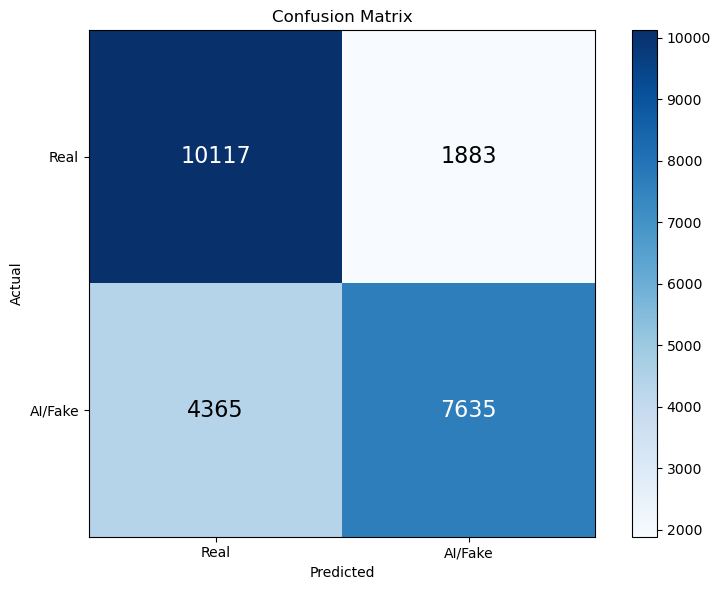

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, ['Real', 'AI/Fake'])
plt.yticks(tick_marks, ['Real', 'AI/Fake'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center", fontsize=16,
                color="white" if cm[i, j] > cm.max()/2 else "black")

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 8: Test Different K Values

In [16]:
from sklearn.model_selection import cross_val_score
import numpy as np

k_values = [1, 3, 5, 7, 9, 11]
cv_results = {}

print("Testing different K values using 5-Fold Cross-Validation...")

for k in k_values:
    print(f"Testing k={k:<2}...", end=" ")
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, metric='euclidean')
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    mean_acc = np.mean(scores)
    cv_results[k] = mean_acc
    print(f"Mean CV Accuracy: {mean_acc:.4f}")
best_k_cv = max(cv_results, key=cv_results.get)
print(f"\nBest K from CV: {best_k_cv} with average accuracy {cv_results[best_k_cv]:.4f}")
print("\n--- Final Evaluation on Test Set ---")

final_knn = KNeighborsClassifier(n_neighbors=best_k_cv, n_jobs=-1, metric='euclidean')
final_knn.fit(X_train_scaled, y_train)

y_pred_final = final_knn.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, y_pred_final)

print(f"Final Accuracy on Test Set (with K={best_k_cv}): {final_accuracy:.4f}")

Testing different K values using 5-Fold Cross-Validation...
Testing k=1 ... Mean CV Accuracy: 0.7504
Testing k=3 ... Mean CV Accuracy: 0.7431
Testing k=5 ... Mean CV Accuracy: 0.7319
Testing k=7 ... Mean CV Accuracy: 0.7259
Testing k=9 ... Mean CV Accuracy: 0.7202
Testing k=11... Mean CV Accuracy: 0.7156

Best K from CV: 1 with average accuracy 0.7504

--- Final Evaluation on Test Set ---
Final Accuracy on Test Set (with K=1): 0.7625


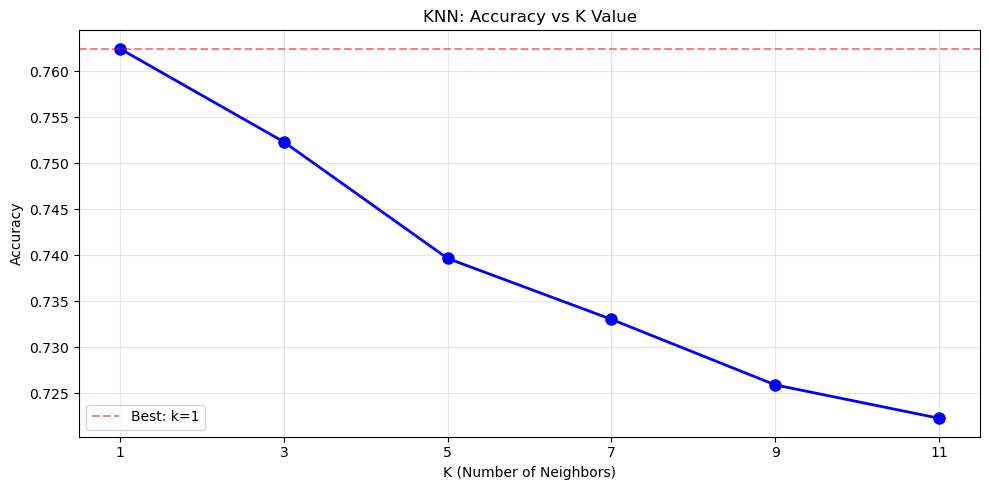

In [17]:
# Plot K vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(list(results.keys()), list(results.values()), 'bo-', linewidth=2, markersize=8)
plt.axhline(y=results[best_k], color='r', linestyle='--', alpha=0.5, label=f'Best: k={best_k}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs K Value')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Step 9: Interactive Demo - Predict Your Own Image

In [18]:
# Retrain with best K
print(f"Retraining with best K={best_k}...")
final_model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1, metric='euclidean')
final_model.fit(X_train_scaled, y_train)
print("Final model ready!")

Retraining with best K=1...
Final model ready!


In [19]:
# Prediction function
def predict_image(image_path, model, scaler):
    """Predict whether an image is AI-generated or real."""
    try:
        img = Image.open(image_path).convert("RGB")
        img = img.resize((32, 32))
        img_array = np.array(img)
        
        # Display image
        plt.figure(figsize=(4, 4))
        plt.imshow(img_array)
        plt.axis('off')
        plt.title("Input Image")
        plt.show()
        
        # Extract features
        features = extract_all_features(img_array).reshape(1, -1)
        features_scaled = scaler.transform(features)
        
        # Predict
        prediction = model.predict(features_scaled)[0]
        probability = model.predict_proba(features_scaled)[0]
        
        label = "AI Generated" if prediction == 1 else "Real Photo"
        confidence = max(probability) * 100
        
        print(f"\nPrediction: {label}")
        print(f"Confidence: {confidence:.1f}%")
        print(f"Probabilities: Real={probability[0]*100:.1f}%, AI/Fake={probability[1]*100:.1f}%")
        
    except Exception as e:
        print(f"Error: {e}")

print("Prediction function ready!")

Prediction function ready!


In [20]:
# Test with sample images from test set
print("Testing with sample images from dataset...")

# Get some random test images
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 5, replace=False)

for idx in sample_indices:
    features = X_test_scaled[idx:idx+1]
    true_label = y_test[idx]
    pred = final_model.predict(features)[0]
    prob = final_model.predict_proba(features)[0]
    
    true_name = "Real" if true_label == 0 else "AI/Fake"
    pred_name = "Real" if pred == 0 else "AI/Fake"
    
    print(f"Sample {idx}: True={true_name}, Pred={pred_name}, "
          f"Conf={max(prob)*100:.1f}%")

Testing with sample images from dataset...
Sample 3111: True=AI/Fake, Pred=Real, Conf=100.0%
Sample 18679: True=AI/Fake, Pred=AI/Fake, Conf=100.0%
Sample 17472: True=AI/Fake, Pred=AI/Fake, Conf=100.0%
Sample 21451: True=Real, Pred=Real, Conf=100.0%
Sample 20800: True=Real, Pred=Real, Conf=100.0%


## To predict your own image, run the cell below:

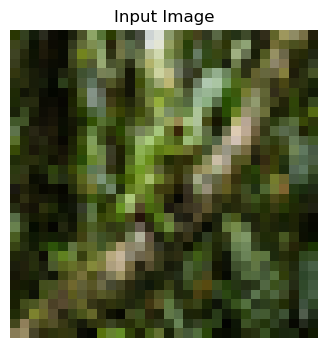


Prediction: AI Generated
Confidence: 100.0%
Probabilities: Real=0.0%, AI/Fake=100.0%


In [22]:
# Uncomment and run with your image path:
# predict_image("path_to_your_image.jpg", final_model, scaler)
predict_image("C:/Users/user1/Downloads/Pic.PNG", final_model, scaler)

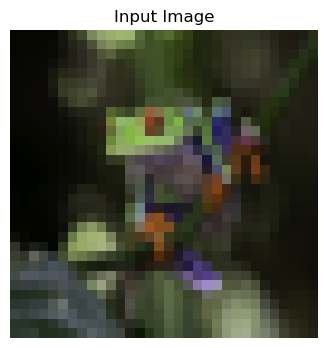


Prediction: Real Photo
Confidence: 100.0%
Probabilities: Real=100.0%, AI/Fake=0.0%


In [23]:
predict_image("C:/Users/user1/Downloads/pic3.PNG", final_model, scaler)